# Projet - Deep Learning

In [74]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import train_test_split

import seaborn as sns
import ipywidgets as widgets

import itertools
import json
from tqdm.notebook import tqdm

import time
import shap
import lime

import joblib
from codecarbon import EmissionsTracker

## Contexte

Le diabète fait partie des maladies chroniques les plus courantes aux États-Unis et touche chaque année des millions de personnes. Cette affection sérieuse se traduit par une mauvaise régulation du sucre dans le sang, ce qui peut, à long terme, réduire la qualité de vie et même l’espérance de vie. Au moment de la digestion, les aliments se transforment en sucres qui passent dans le sang. Cela incite le pancréas à produire de l’insuline, une hormone qui permet aux cellules d’utiliser ces sucres comme source d’énergie. Dans le cas du diabète, soit l’organisme ne produit pas assez d’insuline, soit il réagit mal.

L’excès prolongé de sucre dans le sang augmente les risques de complications graves : maladies cardiovasculaires, perte de la vue, amputations ou encore insuffisance rénale. Même si le diabète ne se guérit pas, il est possible d’en limiter les effets grâce à la perte de poids, à une alimentation adaptée, à une activité physique régulière et à un suivi médical approprié. Plus le diagnostic est posé tôt, plus il est possible d’agir efficacement. C’est pour cette raison que les outils de prédiction du risque de diabète représentent un enjeu important de santé publique.

L’ampleur du phénomène est frappante. Selon les Centres pour le contrôle et la prévention des maladies (CDC) en 2018, 34,2 millions d’Américains vivaient avec un diabète, et 88 millions étaient prédiabétiques. Une personne diabétique sur cinq n’en avait pas conscience, et la grande majorité des personnes prédiabétiques ignorait également leur situation. Le diabète de type 2, la forme la plus fréquente, est influencé par de nombreux facteurs : âge, niveau d’études, revenus, zone géographique, origine ethnique ou encore conditions sociales de vie. Les populations les plus défavorisées sont souvent les plus touchées.

La maladie représente aussi un poids financier immense : le coût du diabète diagnostiqué est estimé à environ 327 milliards de dollars par an, et si l’on inclut le diabète non diagnostiqué et le prédiabète, on approche les 400 milliards de dollars.

**Objectifs :**

Nous sommes chargés de construire un modèle de classification binaire permettant de prédire la probabilité qu’une personne soit diabétique à partir des données médicales issues de l’enquête diabetes_binary_health_indicators_BRFSS201 (BRFSS 2015).

Notre objectif ultime est de maximiser la métrique ROC AUC sur un jeu de test non étiqueté.
En parallèle, nous adopterons une approche MLOps (versioning des données, traçabilité et automatisation des traitements) et nous travaillerons en mode Scrum, selon trois sprints, livrables à chaque itération.

## Présentation du jeu de données

Le Système de surveillance des facteurs de risque comportementaux (BRFSS) est une enquête téléphonique annuelle menée par les Centres pour le contrôle et la prévention des maladies (CDC) sur la santé. Chaque année, cette enquête recueille les réponses de plus de 400 000 Américains sur leurs comportements à risque pour la santé, leurs maladies chroniques et leur recours aux services de prévention. Elle est réalisée chaque année depuis 1984. Pour ce projet, nous avons utilisé un fichier CSV des données disponibles sur [Kaggle](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset) pour l'année 2015. Ce jeu de données contient les réponses de 253 680 personnes et comporte 22 variables. Ces variables correspondent soit à des questions posées directement aux participants, soit à des variables calculées à partir de leurs réponses individuelles.

Les variables du dataset sont :
- **Diabetes_binary :** Objectif de l’étude : indique si la personne est diabétique (1 = Oui, 0 = Non).

- **HighBP :** Indique si le sujet souffre d’hypertension artérielle. 
- **HighChol :** Le sujet a un taux de cholestérol élevé. 
- **CholCheck :** Le sujet a effectué un contrôle du cholestérol dans les 5 dernières années. 
- **BMI :** Indice de masse corporelle. 
- **Smoker :** Le sujet a fumé plus de 100 cigarettes au cours de sa vie. 
- **Stroke :** Le sujet a déjà eu un AVC. 
- **HeartDiseaseorAttack :** Le sujet a déjà eu une maladie coronarienne ou un infarctus du myocarde. 
- **PhysActivity :** Le sujet a pratiqué une activité physique au cours des 30 derniers jours (hors travail). 
- **Fruits :** Le sujet consomme des fruits au moins une fois par jour. 
- **Veggies :** Le sujet consomme des légumes au moins une fois par jour. 
- **HvyAlcoholConsump :** Forte consommation d’alcool (hommes ≥ 14 verres/semaine, femmes ≥ 7). 
- **AnyHealthcare :** Le sujet bénéficie d’une couverture santé (assurance ou mutuelle). 
- **NoDocbcCost :** Le sujet n’a pas consulté un médecin dans les 12 derniers mois à cause du coût. 
- **GenHlth :** État de santé général (1 = excellent, 2 = très bon, 3 = bon, 4 = moyen, 5 = mauvais). 
- **MentHlth :** Nombre de jours de mauvaise santé mentale sur les 30 derniers jours. 
- **PhysHlth :** Nombre de jours de maladie ou blessure sur les 30 derniers jours. 
- **DiffWalk :** Difficulté à marcher ou monter des escaliers. 
- **Sex :** Sexe du sujet (0 = Femme, 1 = Homme). 
- **Age :** Tranche d’âge (1 = 18–24, …, 13 = 80+). 
- **Education :** Niveau d’éducation (1 = jamais scolarisé, …). 
- **Income :** Niveau de revenu (1 < 10k$, …, 8 < 75k$).


### Séparation des données

Il est primordial de séparer les données en deux catégories bien distinctes :
- Variable cible : elle représente le résultat que l’on cherche à prédire ou à expliquer à l’aide du modèle.

- Variables explicatives : elles correspondent aux variables utilisées pour prédire, expliquer ou décrire la variable cible.

Dans ce contexte, la seule variable cible, c'est-à-dire celle que nous allons devoir prédire dans notre projet est **Diabetes_binary**.

Tout le reste des variables sont des variables explicatives. 

On distingue principalement deux types de variables : les variables quantitatives et les variables qualitatives. Cette distinction est essentielle pour choisir les méthodes d’analyse et de modélisation adaptées.

Une variable quantitative (ou numérique) correspond à une information mesurable qui s’exprime par un nombre (ex: Age, poids, température, supercifie, ...). Dans notre contexte les variables sont considérées comme quantitatives continues (variable qui prend un infini de valeurs réelles à l'intérieur d'un intervalle donné) :
- BMI
- MentHlth
- PhysHlth

Une variable qualitative (ou catégorielle) décrit une caractéristique non numérique. Elle représente des catégories ou des états. Il y a 2 types de variables qualitatives : qualitative nominale (étiquetage, binaire) et qualitative ordinale (données définies dans une relation d'ordre entre différentes catégories possibles). Variables qualitatives nominales :
- Diabetes_binary
- HighBP
- HighChol
- CholCheck
- Smoker
- Stroke
- HeartDiseaseorAttack 
- PhysActivity 
- Fruits
- Veggies 
- HvyAlcoholConsump 
- AnyHealthcare
- NoDocbcCost
- DiffWalk
- Sex 

Variables ordinales :
- GenHlth
- Age
- Income
- Education

### Variables sensibles 

À des fins d’anonymisation et de limitation des biais, nous avons choisi de retirer certaines variables non essentielles à la prédiction du diabète.
- **Income :** le niveau de revenu peut être indirectement lié au diabète (accès aux soins, alimentation), mais nous choisissons de l’exclure afin d’éviter d’introduire des biais socio-économiques dans le modèle.
- **Education :** de même, le niveau d’éducation peut influencer certains comportements de santé, mais il n’est pas un facteur médical direct. Nous le retirons afin de limiter les biais et de conserver un modèle centré sur des variables de santé.

Le dataset contient également certaines variables pouvant être considérées comme subjectives. En effet, ces variables reposent sur des auto-évaluations des individus, ce qui peut introduire des biais liés à la perception personnelle ou à l’état mental.
- **GenHlth**
- **MenHlth**
- **PhysHlth**

### Scission des données (Train/Test/Validation)

Afin d'entrainer au mieux notre modèle avec nos données, nous procédons à une séparation du dataset en 3 sous-dataset.

- **Dataset d'entrainement :** Ce jeu de données est utilisé pour entraîner le modèle. Il permet au modèle d’apprendre les relations et les patterns présents dans les données.
- **Dataset de validation :** Ce jeu de données est utilisé pendant l’entraînement pour évaluer les performances du modèle de manière intermédiaire. Il permet d’ajuster les hyperparamètres et de choisir le meilleur modèle, tout en limitant le surapprentissage (overfitting).
- **Dataset de test :** Ce jeu de données est utilisé uniquement à la fin du processus. Il permet d’évaluer les performances finales du modèle sur des données qu’il n’a jamais vues. On compare alors les valeurs prédites aux valeurs réelles afin d’obtenir une estimation fiable de sa capacité de généralisation.

Afin d'assurer une répartition équilibrée des données, nous allons utiliser un découpage de 70% des données dans le dataset d'entrainement, 15% de validation et 15% de données de test. 

## Pré-traitement des données

### Chargement du dataset

In [2]:
path = "Health_Data/diabetes_binary_health_indicators_BRFSS2015.csv"

In [3]:
def load_dataset(path):
    dataset = pd.read_csv(path)
    return dataset

Suppression des variables critiques :

In [4]:
def remove_sensible_data(df, columns_to_remove):
    df = df.copy()
    df = df.drop(columns=columns_to_remove)
    return df

### Gestion des valeurs manquantes

Les valeurs manquantes sont un problème courant dans les ensembles de données réels et peuvent nuire aux performances des modèles de Machine Learning. Il existe plusieurs méthodes pour gérer les valeurs manquantes dans un dataset :
- **Suppression de la ligne :** supprimer les observations contenant des valeurs manquantes peut être pertinent, mais si ces valeurs sont nombreuses, cela peut entraîner une perte importante d’information.
- **Remplir avec la médiane :** méthode robuste, particulièrement adaptée aux variables numériques contenant des valeurs extrêmes (outliers).
- **Remplir avec la moyenne :** adaptée aux variables numériques sans forte présence d’outliers.
- **Remplir avec la valeur suivante (forward fill):** consiste à remplacer la valeur manquante par la valeur suivante dans la série.
- **Remplir avec la valeur précédente (backward fill):** consiste à remplacer la valeur manquante par la valeur précédente.
- **Remplir avec le mode :** remplace la valeur manquante par la valeur la plus fréquente, généralement utilisée pour les variables catégorielles.

Pour toutes nos valeurs, nous avons choisi de remplir les valeurs manquantes par le "mode", c'est à dire la valeur la plus fréquente car toutes nos valeurs sont catégorielles.

In [5]:
def check_missing_values(df):
    missing_values_columns = []
    for i in range(len(df.columns)):
        if df.iloc[:, i].isnull().sum() > 0:
            missing_values_columns.append(df.columns[i])
            print(f"Column {df.columns[i]} has {df.iloc[:, i].isnull().sum()} missing values.")
    
    if not missing_values_columns:
        print("No missing values found in the dataset.")
    return missing_values_columns

def fill_missing_columns(df, missing_columns):
    # Fill with mode
    df[missing_columns] = df[missing_columns].fillna(df[missing_columns].mode().iloc[0])
    print(f"Column {missing_columns} filled with value: {df[missing_columns].mode().iloc[0]}")

    return df

### Gestion des valeurs aberrantes

La gestion des valeurs aberrantes est primordiale pour l'entrainement d'un modèle, des valeurs aberrantes peuvent fortement influencer negativement l'entrainement du modèle en le poussant à apprendre des relations fausses. Pour cela, il existe plusieurs méthodes :
- **Z-score :** On observe de combien d’écarts types la valeur est éloignée de sa moyenne. Si le résultat est > 3 écarts types, la valeur est considérée comme outlier.
- **IQR (Interquartile Range) :** On utilise les quartiles. Toute valeur au-delà de *Q3 + 1.5 * IQR* est considérée comme suspecte.

Après la suppression des données sensibles, il ne reste qu'une variable quantitative qui est BMI. La méthode Z-score est utilisé pour des valeurs avec une distribution normale. Comme nous allons le voir dans la partie suivante, la variable BMI ne suit pas une distribution normale donc nous utiliserons la méthode IQR pour cette donnée. Nous supprimons les lignes doublons.

In [6]:
def outliers_detection(df):

    df = df.copy()

    iqr = df['BMI'].quantile(0.75) - df['BMI'].quantile(0.25)
    lower_bound = df['BMI'].quantile(0.25) - 1.5 * iqr
    upper_bound = df['BMI'].quantile(0.75) + 1.5 * iqr

    outlier_number = (df['BMI'] < lower_bound).sum() + (df['BMI'] > upper_bound).sum()

    df = df[(df['BMI'] >= lower_bound) & (df['BMI'] <= upper_bound)]
    print(f"Outliers removed! Lower bound: {lower_bound}, Upper bound: {upper_bound}, Number of outliers removed: {outlier_number}")    
    return df

### Normalisation des données

La normalisation (ou feature scaling) est l'étape qui permet de mettre toutes tes variables sur la même échelle. Sans cela, un réseau de neurones donnera 1000 fois plus d'importance à une variable "Salaire" (ex: 50 000) qu'à une variable "Âge" (ex: 30), simplement parce que le chiffre est plus grand.
Les méthodes de normalisations selon les cas d’usages :
- **Min-Max-Scaling :** C'est la méthode qui écrase les données dans un intervalle fixe, généralement [0, 1]. Très utile quand les valeurs ont des bornes connues et censés ne pas être dépassées. 
- **Standardisation :** Transformation des données pour qu'elles aient une moyenne de 0 et un écart-type de 1. C'est la méthode par défaut pour la plupart des algorithmes de Machine Learning et de Deep Learning.

In [7]:
def normalize_data(df, columns):
    df = df.copy()
    scaler = MinMaxScaler()
    
    df[columns] = scaler.fit_transform(df[columns])
    
    return df, scaler

Nous utiliserons la méthode de normalisation Min-Max-Scaling pour la variable BMI, car elle a des bornes connues (généralement entre 10 et 50) et nous voulons que toutes les valeurs soient comprises entre 0 et 1 pour faciliter l'apprentissage du modèle.

### Gestion des doublons

Les doublons peuvent influencer négativement l'entraînement du modèle en introduisant un biais dans les données. En effet, si une même observation est présente plusieurs fois, le modèle peut lui accorder une importance disproportionnée, ce qui peut fausser les résultats et réduire la capacité de généralisation du modèle. Par conséquent, il est essentiel de détecter et de supprimer les doublons pour garantir que le modèle apprend à partir d'un ensemble de données représentatif et équilibré. Sachant que notre dans notre dataset, nous n’avons aucune variable qui pourrait être considérée comme un "identifiant unique" (comme un ID, numéro de téléphone, ...), nous allons considérer un doublons comme exactement la même ligne de données qui sera présente 2 fois ou plus dans notre dataset.

In [8]:
def manage_doublons(df):
    df = df.copy()

    nb_duplicates = df.duplicated().sum()

    df = df.drop_duplicates(keep='first')
    print(f"Doublons removed! Number of doublons removed: {nb_duplicates}")
    return df

### Chargement des données

In [9]:
df_data = load_dataset(path)

df_data = remove_sensible_data(df_data, ['GenHlth', 'MentHlth', 'PhysHlth', 'Income', 'Education'])

quantitative_columns = ['BMI', 'Age']

### Analyse exploratoire quantitative

Cette section présente une analyse statistique du jeu de données afin de mieux comprendre 
la distribution des variables, leurs relations et la présence éventuelle de déséquilibres.

In [10]:
# Résumé statistique enrichi
print("=== Statistiques descriptives ===")
display(df_data.describe().T.style.background_gradient(cmap='Blues'))

# Distribution de la variable cible
print("\n=== Distribution de Diabetes_binary ===")
target_counts = df_data['Diabetes_binary'].value_counts()
target_pct    = df_data['Diabetes_binary'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': target_counts, 'Pourcentage (%)': target_pct.round(2)}))

=== Statistiques descriptives ===


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.000000,0.139333,0.346294,0.000000,0.000000,0.000000,0.000000,1.000000
HighBP,253680.000000,0.429001,0.494934,0.000000,0.000000,0.000000,1.000000,1.000000
HighChol,253680.000000,0.424121,0.494210,0.000000,0.000000,0.000000,1.000000,1.000000
CholCheck,253680.000000,0.962670,0.189571,0.000000,1.000000,1.000000,1.000000,1.000000
BMI,253680.000000,28.382364,6.608694,12.000000,24.000000,27.000000,31.000000,98.000000
Smoker,253680.000000,0.443169,0.496761,0.000000,0.000000,0.000000,1.000000,1.000000
Stroke,253680.000000,0.040571,0.197294,0.000000,0.000000,0.000000,0.000000,1.000000
HeartDiseaseorAttack,253680.000000,0.094186,0.292087,0.000000,0.000000,0.000000,0.000000,1.000000
PhysActivity,253680.000000,0.756544,0.429169,0.000000,1.000000,1.000000,1.000000,1.000000
Fruits,253680.000000,0.634256,0.481639,0.000000,0.000000,1.000000,1.000000,1.000000



=== Distribution de Diabetes_binary ===
                  Count  Pourcentage (%)
Diabetes_binary                         
0.0              218334            86.07
1.0               35346            13.93


Le dataset est **déséquilibré** : la classe 0 (non-diabétique) représente environ 86% des observations contre 14% pour la classe 1. Ce déséquilibre devra être pris en compte lors de l'entraînement du modèle (ex : class_weight, SMOTE, etc.). Nous pouvons également observer les valeurs non normalisées de la variable BMI, qui est la seule variable quantitative du dataset restante et qui devra être normalisée avant l'entrainement du modèle. Nous comparerons la version brute à la version normalisée de cette variable dans la section suivante.

Une matrice de corrélation permet d'avoir une vue d'ensemble de la corrélation entre les variables explicatives et la variable cible. Nous allons afficher une Heatmap de la corrélation de Spearman (corrélation adapté pour les variables ordinales) afin de nous permettre d'avoir une représentation graphique.

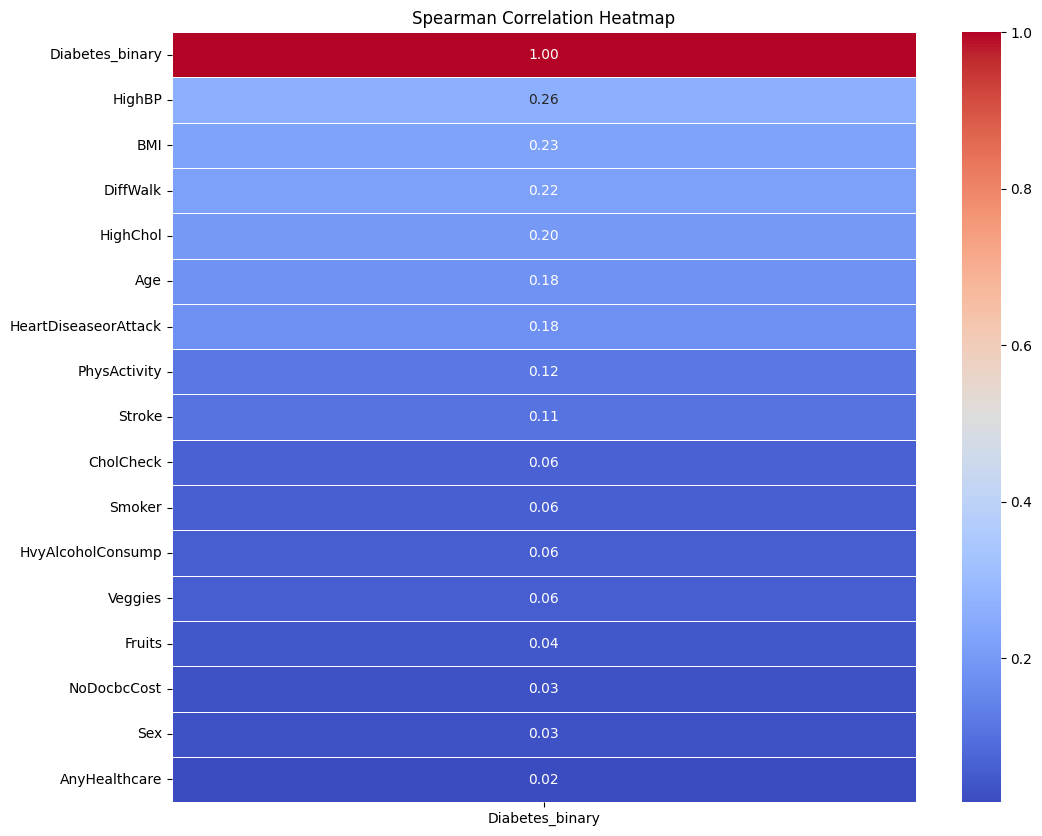

In [11]:
corr_pearso = df_data.corr(method='spearman')[['Diabetes_binary']].abs().sort_values(by='Diabetes_binary', ascending=False)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_pearso, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation Heatmap")
plt.show()

### Analyse exploratoire qualitative (EDA visuelle)


L'objectif est ici de visualiser graphiquement les distributions et les relations entre variables afin de dégager des tendances interprétables. Nous allons nous concentrer uniquement sur l'unique variable quantitative (BMI) car les autres variables sont catégorielles.

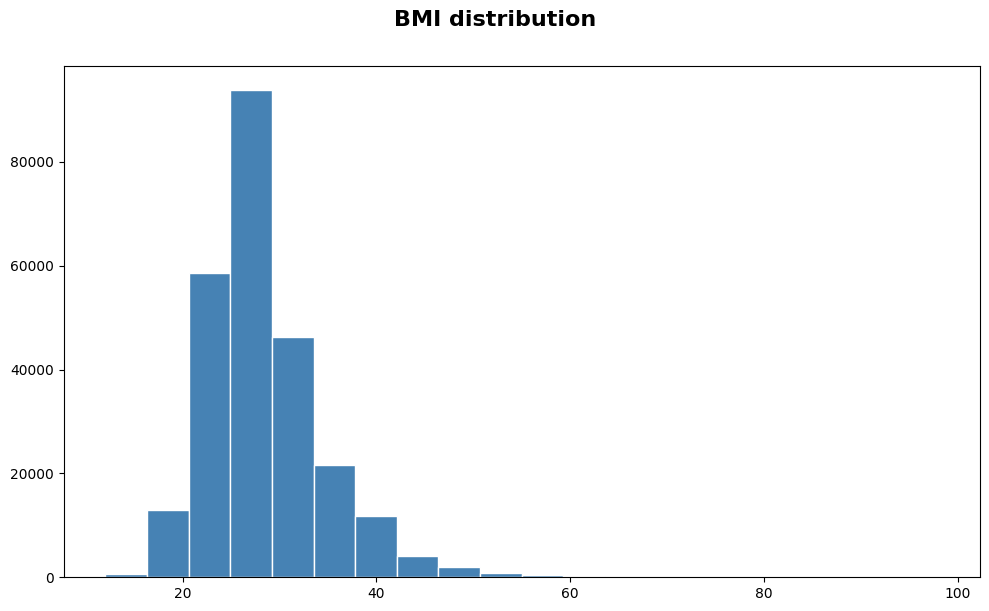

In [12]:
# Distribution de la variable BMI
df_data['BMI'].hist(figsize=(10, 6), bins=20, color='steelblue', edgecolor='white', grid=False)
plt.suptitle("BMI distribution", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Nous pouvons voir que la distribution de la variable BMI n'est pas normale, elle est plutôt asymétrique. Cela nous permettra de nous orienter vers des méthodes de pré-traitement adapté à ce type de distribution.

Les graphiques de boite à moustache (boxplot) permettent de visualiser la distribution d'une variable quantitative (BMI) en fonction d'une variable catégorielle (Diabetes_binary). Ils montrent la médiane, les quartiles et les valeurs extrêmes.

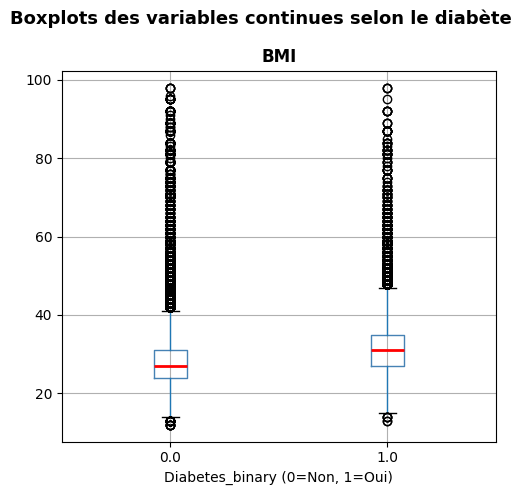

In [13]:
# Boxplots des variables continues selon Diabetes_binary
continuous_cols = ['BMI']

fig, axes = plt.subplots(1, len(continuous_cols), figsize=(5 * len(continuous_cols), 5))
if len(continuous_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, continuous_cols):
    df_data.boxplot(column=col, by='Diabetes_binary', ax=ax,
                    boxprops=dict(color='steelblue'),
                    medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel("Diabetes_binary (0=Non, 1=Oui)")

plt.suptitle("Boxplots des variables continues selon le diabète", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

La variable BMI contient un grand nombre de valeurs extrêmes (outliers) qui peuvent potentiellement influencer négativement l'entraînement du modèle.  Nous savons désormais qu'il nous faut gérer impérativement ces valeurs aberrantes avant d'entraîner notre modèle.

In [14]:
def save_dataset(train, val, test, path):
    train.to_csv(f"{path}train_dataset.csv", index=False)
    val.to_csv(f"{path}val_dataset.csv", index=False)
    test.to_csv(f"{path}test_dataset.csv", index=False)
    print("Dataset saved to:", path)

In [15]:
def split_dataset(df):
    train, temp = train_test_split(df, test_size=0.3, random_state=42)
    val, test = train_test_split(temp, test_size=0.5, random_state=42)

    df_0 = train[train['Diabetes_binary'] == 0]
    df_1 = train[train['Diabetes_binary'] == 1]

    min_size = min(len(df_0), len(df_1))

    df_0_balanced = df_0.sample(min_size, random_state=42)
    df_1_balanced = df_1.sample(min_size, random_state=42)

    train_balanced = pd.concat([df_0_balanced, df_1_balanced])

    return train_balanced, val, test

### Traitement (main)

In [16]:
# Gestion des doublons
df_data = manage_doublons(df_data)

# Vérification des valeurs manquantes
columns_missing = check_missing_values(df_data)
if columns_missing:
    df_data = fill_missing_columns(df_data, columns_missing)

# Détection des outliers
df_data = outliers_detection(df_data)

# Normalisation
df_data, scaler = normalize_data(df_data, quantitative_columns)

# Split du dataset
train, val, test = split_dataset(df_data)

# Save du dataset nettoyé
# save_dataset(train, val, test, "Health_Data/")

Doublons removed! Number of doublons removed: 148287
No missing values found in the dataset.
Outliers removed! Lower bound: 11.5, Upper bound: 47.5, Number of outliers removed: 3300


Maintenant que nous avons effectué un traitement complet de nos données, nous allons analyser les données après le traitement afin de vérifier que les différentes étapes ont été correctement appliquées et que les données sont prêtes pour l'entraînement du modèle.

In [17]:
# Résumé statistique post-traitement
print("=== Statistiques descriptives ===")
display(df_data.describe().T.style.background_gradient(cmap='Blues'))

=== Statistiques descriptives ===


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,102093.000000,0.240310,0.427274,0.000000,0.000000,0.000000,0.000000,1.000000
HighBP,102093.000000,0.530742,0.499057,0.000000,0.000000,1.000000,1.000000,1.000000
HighChol,102093.000000,0.492130,0.499941,0.000000,0.000000,0.000000,1.000000,1.000000
CholCheck,102093.000000,0.931180,0.253148,0.000000,1.000000,1.000000,1.000000,1.000000
BMI,102093.000000,0.499780,0.185744,0.000000,0.371429,0.485714,0.628571,1.000000
Smoker,102093.000000,0.529987,0.499102,0.000000,0.000000,1.000000,1.000000,1.000000
Stroke,102093.000000,0.090564,0.286990,0.000000,0.000000,0.000000,0.000000,1.000000
HeartDiseaseorAttack,102093.000000,0.174782,0.379782,0.000000,0.000000,0.000000,0.000000,1.000000
PhysActivity,102093.000000,0.611462,0.487420,0.000000,0.000000,1.000000,1.000000,1.000000
Fruits,102093.000000,0.533474,0.498881,0.000000,0.000000,1.000000,1.000000,1.000000


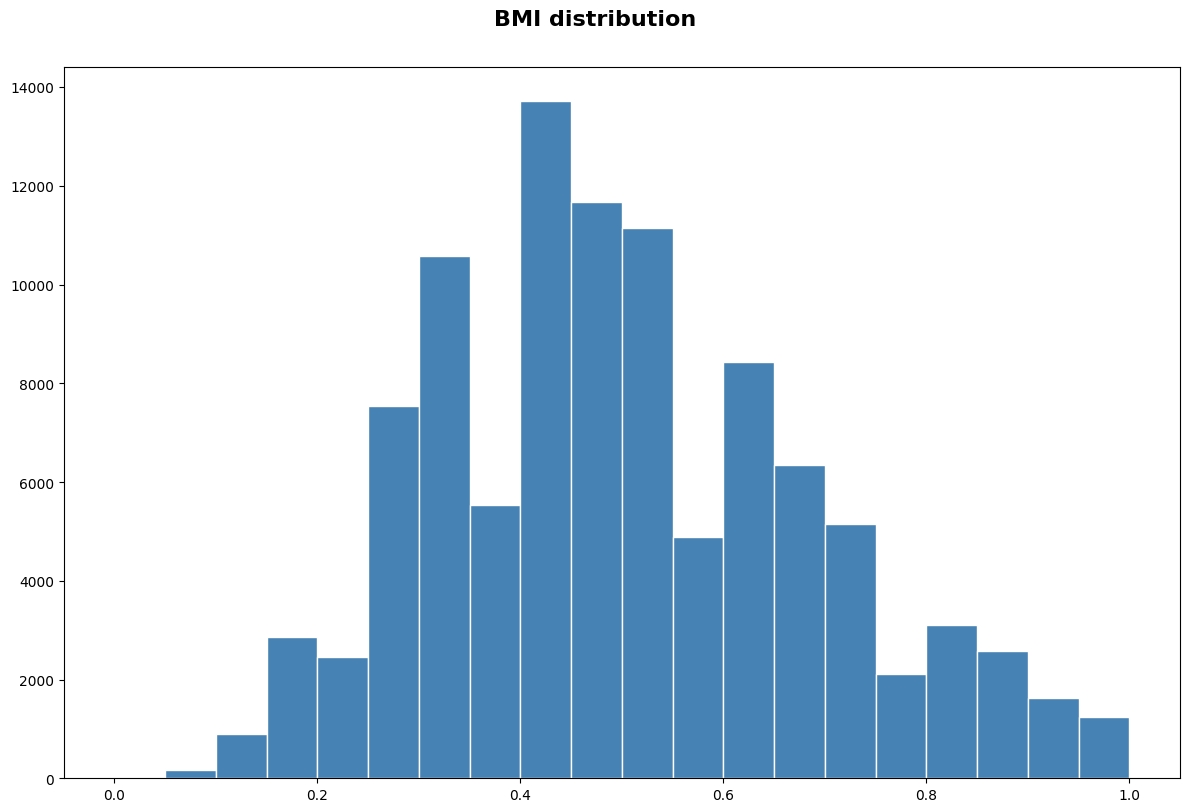

In [18]:
# Distribution de la variable BMI après traitement
df_data['BMI'].hist(figsize=(12, 8), bins=20, color='steelblue', edgecolor='white', grid=False)
plt.suptitle("BMI distribution", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

La variable BMI à été normalisée entre 0 et 1, ce qui évitera à notre modèle d'être biaisé par l'échelle des données et lui permettra d'apprendre plus efficacement. On voit également qu'il suit une loi normale après le traitement des outliers, ce qui est un bon signe pour l'entraînement du modèle. Nous avons également supprimé les doublons, ce qui garantit que notre modèle n'apprendra pas à partir de données redondantes et biaisées.

In [19]:
temp_df = load_dataset("Health_Data/train_dataset.csv")

print("\n=== Distribution de Diabetes_binary ===")
target_counts = temp_df['Diabetes_binary'].value_counts()
target_pct    = temp_df['Diabetes_binary'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': target_counts, 'Pourcentage (%)': target_pct.round(2)}))


=== Distribution de Diabetes_binary ===
                 Count  Pourcentage (%)
Diabetes_binary                        
0.0              17225             50.0
1.0              17225             50.0


Nous avons vérifié que notre dataset de train est désormais également équilibré.  

## Architecture du modèle

Pour l'architecture de notre modèle, il va nous falloir déterminer plusieurs paramètres de la structure de notre modèle qui seront crutiaux pour son entrainement. Voici les principaux paramètres à définir :
- **Nombre de couches cachées,**
- **Nombre de neurones par couche,**
- **Fonction d'activation,**
- **Fonction de perte,**
- **Hyperparamètres du modèle** (taux d'apprentissage, nombre d'itérations, ...), 
- **Méthodes anti-surapprentissage.**

### Définition du nombre de couches cachées

Une couche cachée dans un réseau de neurones est une couche intermédiaire située entre la couche d'entrée et la couche de sortie. Elle est constituée d'un nombre de neurones qui effectuent des calculs sur les données d'entrée pour extraire des caractéristiques et apprendre des représentations complexes. 
Le nombre de couches cachées influent directement sur le raisonnement du modèle. En effet, plus il y a de couches cachées, plus le modèle peut apprendre des représentations théoriquement complexes, cependant, cela peut aussi entraîner un surapprentissage si le modèle est trop complexe par rapport à la quantité de données disponibles. Il est donc important de trouver l'équilibre entre la complexité du modèle et la quantité de données pour éviter le surapprentissage tout en permettant au modèle d'apprendre les représentations de nos données.

Nous allons faire le tests de différents nombre de couches cachées (entre 2 et 4) afin de trouver quel nombre de couches cachées nous permet d'obtenir les meilleurs résultats.  

### Définition du nombre de neurones par couches

Le nombre de neurones par couche est un paramètre clé dans la conception d'un réseau de neurones. Les neurones correspondent à des unités de calcul (fonctions) qui vont effectuer des calculs sur les données et donc apprendre concrètement les relations. 
Le nombre de neurones influence également la capacité du modèle à apprendre, un nombre faible de neurones peut limiter sa capacité à capturer des relations complexes, tandis qu'un nombre trop élevé peut entrainer un surapprentissage. Encore une fois, il faut trouver le bon équilibre entre le nombre de neurones et la quantité de données.

Le nombre de neurones par couche est généralement de 32, 64 ou 128. Toutes les couches cachées de notre modèle ne sont pas nécessairement composées du même nombre de neurones, nous allons faire le test de différentes combinaisons de nombre de neurones par couches pour optimiser les résultats.

### Définition des fonctions d'activation

#### Différentes formes de fonctions d'activation

* **ReLU (Rectified Linear Unit) :** La fonction la plus utilisée pour les couches cachées ($f(x) = \max(0, x)$). Elle évite la disparition du gradient et accélère la convergence.
* **Sigmoïde :** Elle transforme les valeurs en une probabilité comprise entre 0 et 1 ($f(x) = \frac{1}{1 + e^{-x}}$). Elle est particulièrement adaptée à la classification binaire en sortie de modèle.
* **Tanh (Tangente Hyperbolique) :** Semblable à la sigmoïde mais centrée en zéro, avec des valeurs allant de -1 à 1.
* **Softmax :** Utilisée pour la classification multi-classe pour obtenir une distribution de probabilité sur plusieurs catégories.

![Différentes fonctions d'activation](https://miro.medium.com/1*ZafDv3VUm60Eh10OeJu1vw.png)

#### Choix de la fonction dans ce projet

Pour ce modèle de prédiction du diabète, le choix s'est porté sur :

* **Couches cachées :** L'utilisation de **ReLU** est privilégiée pour sa capacité à traiter efficacement les données structurées après leur normalisation par *Min-Max-Scaling* (notamment pour la variable BMI).
* **Couche de sortie :** Comme l'objectif est une **classification binaire** (déterminer si `Diabetes_binary` est 0 ou 1), la fonction **Sigmoïde** est utilisée pour obtenir une probabilité d'appartenance à la classe positive.

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [5]:
def relu(x):
    return np.maximum(0, x)

def relu_prime(z):
    return (z > 0).astype(float)

### Défintion de la fonction de perte

La fonction de perte ou de coût (Loss Function) est la quantification de l'écart entre les prévisions du modèle et les observations réelles du jeu de donnée utilisé pendant l'entraînement. Il existe donc plusieurs fonctions de perte adaptées à différents types de problèmes et de données :
- **MSE (Mean Squared Error) :** utilisée pour les problèmes de régression, elle mesure la moyenne des carrés des erreurs entre les prédictions et les valeurs réelles.
- **Cross-Entropy Loss :** utilisée pour les problèmes de classification, elle mesure la distance entre les distributions de probabilité prédites et les distributions de probabilité réelles.
- **Hinge Loss :** utilisée pour les problèmes de classification binaire, notamment avec les SVM, elle mesure la marge de séparation entre les classes.

Dans notre cas, nous allons utiliser la fonction de perte **Cross-Entropy Loss** car nous sommes dans un contexte de classification binaire. Cette fonction est particulièrement adaptée pour mesurer la distance entre les probabilités prédites par le modèle (grâce à la fonction d'activation Sigmoïde) et les étiquettes réelles (0 ou 1) de notre variable cible `Diabetes_binary`.

In [6]:
def loss_function(y_true, y_pred, pos_weight=1.0, neg_weight=1.0):
    y_pred = np.clip(y_pred, 1e-15, 1-1e-15)
    weights = y_true * pos_weight + (1 - y_true) * neg_weight
    loss = -np.mean(weights * (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)))
    return loss    

### Définition des hyperparamètres du modèle

Afin de faire la recherche des meilleurs hyperparamètres pour nos modèles, nous devons trouver une méthode pour créer des modèles de manière dynamique et non static. Avec cette méthode, nous allons pouvoir créer des modèles avec des couches cachées totalement paramétrables au niveau nombre de couches, nombre de neurones par couche et fonction d'activation. 

Nous avons défini une liste de combinaisons de modèles arbitrairement choisies pour faire la recherche des meilleurs hyperparamètres.

In [7]:
neural_dict = {
    "neural_info_1": {
        "input_size": 16,
        "hidden_params": [
            {"hidden_size": 128, "activation": relu, "activation_prime": relu_prime},
            {"hidden_size": 64, "activation": relu, "activation_prime": relu_prime},
            {"hidden_size": 32, "activation": relu, "activation_prime": relu_prime}
        ],
        "output_params": [
            {"output_size": 1, "activation": sigmoid}
        ]
    },

    "neural_info_2": {
        "input_size": 16,
        "hidden_params": [
            {"hidden_size": 128, "activation": relu, "activation_prime": relu_prime},
            {"hidden_size": 64, "activation": relu, "activation_prime": relu_prime},
            {"hidden_size": 64, "activation": relu, "activation_prime": relu_prime}
        ],
        "output_params": [
            {"output_size": 1, "activation": sigmoid}
        ]
    },

    "neural_info_3": {
        "input_size": 16,
        "hidden_params": [
            {"hidden_size": 64, "activation": relu, "activation_prime": relu_prime},
            {"hidden_size": 64, "activation": relu, "activation_prime": relu_prime},
            {"hidden_size": 32, "activation": relu, "activation_prime": relu_prime},
            {"hidden_size": 32, "activation": relu, "activation_prime": relu_prime}
        ],
        "output_params": [
            {"output_size": 1, "activation": sigmoid}
        ]
    }
}

## Métriques d’évaluation

Afin d'évaluer les performances de notre modèle, nous allons utiliser plusieurs métriques d'évaluation adaptées à la classification. Ces métriques vont également nous permettre de comparer lors de la phase de test les différentes versions de notre modèle et ainsi choisir la meilleure version.

### Accuracy (Justesse)

**L'accuracy** (justesse) correpond à la proportion de prédictions correctes quelque soit la classe prédite. C'est une métrique basique qui permet d'évaluer si notre modèle a bien appris à différencier les classes, cependant, dans le cas d'un dataset déséquilibré, l'accuracy peut être trompeuse. En effet, si la classe majoritaire représente 90% des données, un modèle qui prédit systématiquement cette classe aura une accuracy de 90% sans pour autant être performant pour la classe minoritaire.

Formule de l'accuracy :
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

Avec :
- TP (True Positives) : nombre de vrais positifs (prédits positifs et réels positifs)
- TN (True Negatives) : nombre de vrais négatifs (prédits négatifs et réels négatifs)
- FP (False Positives) : nombre de faux positifs (prédits positifs et réels négatifs)
- FN (False Negatives) : nombre de faux négatifs (prédits négatifs et réels positifs)

### Recall (Rappel)

Le **recall** (rappel ou taux de vrais positifs) correspond à la proportion de valeurs positifs qui l'ont réellement été prédit comme positifs. Cette métrique est très important dans notre contexte, car l’objectif est d’identifier toutes les personnes réellement diabétiques. Il est donc essentiel de prédire correctement un patient diabétique plutôt que de le classer à tort comme non diabétique, ce qui correspond à un faux négatif. Dans ce contexte, le faux négatif est l’erreur la plus grave, puisqu’un patient diabétique non détecté risque de ne pas recevoir la prise en charge nécessaire.

Formule du recall :
$$Recall = \frac{TP}{TP + FN}$$

### Précision

La **précision** correspond à la proportion de valeurs prédites comme positives qui sont réellement positives. Dans notre contexte, cette métrique reste importante, mais elle est moins prioritaire que le recall. En effet, la précision mesure la capacité du modèle à limiter les faux positifs, c’est-à-dire les patients classés à tort comme diabétiques alors qu’ils ne le sont pas.

Formule de la précision :
$$Precision = \frac{TP}{TP + FP}$$

### F1 score

Le **F1 score** correpond à la moyenne harmonique entre la précision et le recall. Il équilibre le compromis entre les faux positifs et les faux négatifs, et fournit une mesure plus précise des performances du modèle. Particulièrement important dans notre contexte car le F1 score va servir d'évaluation globale de notre modèle en prenant en compte à la fois la précision et le recall. 

Formule du F1 score :
$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

### F2 score

Le **F2 score** est une variante du F1 score qui accorde plus de poids à l'une des variables (précision ou recall) en fonction de leur importance dans le contexte. Le F2 score est souvent utilisé dans le contexte de diagnostics médicaux, où il est préférable d'avoir une fausse alarme (faux positif) plutôt que de manquer le diagnostic d'une maladie (faux négatif). En accordant plus de poids au recall, le F2 score permet de privilégier la détection des cas positifs, même au prix d'une augmentation de faux positifs.
Formule du F2 score :
$$F2 = (1 + a^2) \times \frac{Precision \times Recall}{Precision + (a^2 \times Recall)}$$

Avec :
- $a$ : poids que l'on va accorder au recall par rapport au recall.

### Implémentation (code)

In [8]:
def accuracy(y_true, y_pred):
    y_pred_labels = (y_pred >= 0.5).astype(int)
    return np.mean(y_true == y_pred_labels)

def precision(y_true, y_pred):
    y_pred_labels = (y_pred >= 0.5).astype(int)
    tp = np.sum((y_true == 1) & (y_pred_labels == 1))
    fp = np.sum((y_true == 0) & (y_pred_labels == 1))
    return tp / (tp + fp + 1e-15)

def recall(y_true, y_pred):
    y_pred_labels = (y_pred >= 0.5).astype(int)
    tp = np.sum((y_true == 1) & (y_pred_labels == 1))
    fn = np.sum((y_true == 1) & (y_pred_labels == 0))
    return tp / (tp + fn + 1e-15)

def f1_score(y_true, y_pred):
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * (p * r) / (p + r + 1e-15)

def f2_score(y_true, y_pred, beta=2):
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return (1 + beta**2) * (p * r) / ((beta**2 * p) + r + 1e-15)

### Gestion du surapprentissage

Un des plus grand problème que peut rencontrer un modèle lors de son entrainement est le surapprentissage (overfitting). Le surapprentissage consiste à créer un modèle qui correspond (mémorise) si étroitement à l'ensemble d'entraînement qu'il ne parvient pas à effectuer des prédictions correctes avec de nouvelles données. Un modèle sur adapté est semblable à une invention qui fonctionne bien en laboratoire, mais qui est sans valeur dans le monde réel.

Il y a plusieurs méthodes pour limiter le surapprentissage :
- **Régularisation L2 (Ridge) :** ajoute une pénalité proportionnelle au carré des poids du modèle, ce qui encourage les poids à être plus petits et réduit la complexité du modèle.
- **Dropout :** consiste à désactiver aléatoirement un pourcentage de neurones pendant l'entraînement, ce qui empêche le modèle de devenir trop dépendant de certains neurones et encourage une meilleure généralisation.

Nous avons implémenté ces deux méthodes pour l'entrainement de notre modèle afin de limiter les risques de surapprentissage. Les hyperparamètres de ces méthodes seront modifiés lors de la phase d'optimisation.

## Implémentation du modèle

Pour créer notre modèle, nous avons du recoder à la main l'apprentissage du modèle c'est à dire les différentes phases de l'apprentissage. Ces phases constituent l'essentiel de l'apprentissage du modèle il faut donc les implémenter correctement pour que notre modèle puisse apprendre efficacement à partir de nos données. 
Il faut donc distinguer deux phases dans l'apprentissage du modèle : 
- **Forward Propagation**
- **Backward Propagation**

#### Forward Propagation

La phase de forward propagation correspond à la phase où les données d'entrées sont passés à travers les différentes couches du modèle afin d'obtenir une prédiction. C'est la phase où le modèle effectue les calculs nécessaires pour transformer les données d'entrée en une prédiction. 
Dans cette phase, les données d'entrée sont multipliées par les poids de chaque neurone puis on y ajoute le biais, c'est la phase d'agrégation. La formule est la suivante :
$$z = w \cdot x + b$$
Avec :
- $z$ : sortie du neurone avant activation
- $w$ : poids du neurone
- $x$ : données d'entrée
- $b$ : biais du neurone

Ensuite, on applique une fonction d'activation à la sortie du neurone pour introduire la non-linéarité dans le modèle. La formule est la suivante :
$$a = f(z)$$
Avec :
- $a$ : sortie du neurone après activation
- $f$ : fonction d'activation

Finalement, à la fin de la phase de forward propagation, on obtient une prédiction qui est comparée à la valeur réelle pour calculer la perte (loss) du modèle.

#### Backward Propagation

Le but de la phase de backward propagation est de mettre à jour les poids du modèle en fonction de la perte calculée lors de la phase de forward propagation. C'est lors de cette phase que le modèle va ajuster ses paramètres pour "apprendre" et donc minimiser la perte. 
Dans un premier temps, on calcule l'erreur de chaque neurone en fonction de la perte (l'erreur est utile pour le calcul du gradient). L’erreur est une valeur unique par neurone qui indique la différence entre ce qui va sortir du neurone et la vrai valeur qui aurait dû sortir $y$. 

La formule est la suivante pour la couche de sortie : 
$$\delta_l = \frac{\partial L}{\partial z_l} = (a_l - y)$$
Avec :
- $\delta_l$ : erreur du neurone de la couche $l$
- $a_l$ : sortie du neurone de la couche $l$ après activation
- $y$ : valeur réelle

La formule pour les couches cachées est la suivante :
$$\delta_l = \frac{\partial L}{\partial z_l} = (w_{l+1}^T \cdot \delta_{l+1}) \odot f'(z_l)$$
Avec :
- $\delta_l$ : erreur du neurone de la couche $l$
- $w_{l+1}$ : poids de la couche $l+1$
- $\delta_{l+1}$ : erreur du neurone de la couche $l+1$
- $f'(z_l)$ : dérivée de la fonction d'activation de la couche $l$

La transposée apparaît parce qu’on ne veut plus parcourir les lignes de $W_{l+1}$ (qui décrivent comment un neurone de la couche suivante reçoit ses entrées), mais les colonnes de $\mathbf{W}_{l+1}^T$ (qui décrivent comment un neurone de la couche actuelle influence tous les neurones suivants).
Après avoir calculé l'erreur de chaque neurone, on peut calculer le gradient de la perte par rapport aux poids du modèle. Le gradient correspond à la dérivée de la loss par rapport aux paramètres (poids et biais). Il indique comment modifier les paramètres pour réduire l’erreur. Il sert de direction et amplitude du changement recommandé. 

La formule pour le gradient des poids est la suivante :
$$\frac{\partial L}{\partial w_l} = a_{l-1}^T \cdot \delta_l$$
Avec :
- $\frac{\partial L}{\partial w_l}$ : gradient de la perte par rapport aux poids de la couche $l$
- $a_{l-1}$ : sortie du neurone de la couche $l-1$ après activation
- $\delta_l$ : erreur du neurone de la couche $l$

La formule pour le gradient des biais est la suivante :
$$\frac{\partial L}{\partial b_l} = \delta_l$$
Avec :
- $\frac{\partial L}{\partial b_l}$ : gradient de la perte par rapport aux biais de la couche $l$

Après avoir calculé les gradients, on peut mettre à jour les poids et les biais du modèle en utilisant la règle de mise à jour suivante :
$$w_l = w_l - \alpha \cdot \frac{\partial L}{\partial w_l}$$
$$b_l = b_l - \alpha \cdot \frac{\partial L}{\partial b_l}$$
Avec :
- $w_l$ : poids de la couche $l$
- $b_l$ : biais de la couche $l$
- $\alpha$ : taux d'apprentissage

Nous pouvons donc implémenter ces différentes étapes dans notre code pour l'entrainement de notre modèle. Nous allons également implémenter les méthodes de régularisation L2, de dropout et Early Stopping pour limiter le surapprentissage.
Nous nous sommes également basé sur la méthode He initialization pour l'initialisation des poids de notre modèle, qui est une méthode d'initialisation adaptée pour les fonctions d'activation ReLU.


In [146]:
class MLP:
    def __init__(self, neural_info, alpha=0.01, dropout_rate=0.2, lambda_l2=0.001, batch_size=32, epoch=10, patience=10,verbosity=False, model_seed=42):
        self.model_seed = model_seed
        self.neural_info = neural_info
        self.W1 = np.random.randn(neural_info["input_size"], neural_info["hidden_params"][0]["hidden_size"]) * np.sqrt(2 / neural_info["input_size"])
        self.b1 = np.zeros((1, neural_info["hidden_params"][0]["hidden_size"]))

        for i in range(1, len(neural_info["hidden_params"])):
            prev_size = neural_info["hidden_params"][i-1]["hidden_size"]
            curr_size = neural_info["hidden_params"][i]["hidden_size"]
            setattr(self, f"W{i+1}", np.random.randn(prev_size, curr_size) * np.sqrt(2 / prev_size))
            setattr(self, f"b{i+1}", np.zeros((1, curr_size)))
        
        last_hidden = neural_info["hidden_params"][-1]["hidden_size"]
        output_size = neural_info["output_params"][0]["output_size"]
        
        self.W_out = np.random.randn(last_hidden, output_size) * np.sqrt(1 / last_hidden)
        self.b_out = np.zeros((1, output_size))

        self.alpha = alpha
        self.dropout_rate = dropout_rate
        self.lambda_l2 = lambda_l2
        self.batch_size = batch_size
        self.epoch = epoch
        self.verbosity = verbosity
        self.patience = patience
        self.optimized_threshold = 0.5


    def dropout(self, A, dropout_rate):
        if dropout_rate == 0:
            return A, np.ones_like(A)
        mask = (np.random.rand(*A.shape) > dropout_rate).astype(float)
        return (A * mask) / (1 - dropout_rate), mask
    
    def l2_regularization(self, lambda_l2):
        l2_loss = 0
        for i in range(1, len(self.neural_info["hidden_params"]) + 1):
            W = getattr(self, f"W{i}")
            l2_loss += np.sum(W ** 2)
        l2_loss += np.sum(self.W_out ** 2)
        return (lambda_l2 / 2) * l2_loss
        

    def fit(self, X, Y, validation_data=None, min_delta=0.001):
            m = X.shape[0]
            self.precision_history = []
            self.accuracy_history = []
            self.f1_history = []
            self.recall_history = []
            self.f2_history = []
            self.loss_history = []

            self.val_f2_history = []
            self.val_cost_history = []

            if self.model_seed is not None:
                np.random.seed(self.model_seed)
            
            best_val_loss = float("inf")
            patience_counter = 0
            best_weights = None
            self.min_delta = min_delta
            
            for e in range(self.epoch):
                indices = np.random.permutation(m)
                X_shuffled = X[indices]
                Y_shuffled = Y[indices]

                num_batches = max(1, m // self.batch_size)

                epoch_loss = 0

                for batch in range(num_batches):
                    start_batch = batch * self.batch_size
                    end_batch = start_batch + self.batch_size

                    X_batch = X_shuffled[start_batch:end_batch]
                    Y_batch = Y_shuffled[start_batch:end_batch]
                    m_b = X_batch.shape[0]

                    # ╭────────────────────────────────────────────────────────╮
                    # │                        FORWARD                         │
                    # ╰────────────────────────────────────────────────────────╯


                    A = X_batch
                    self.As = [X_batch]
                    self.Zs = []
                    dropout_masks = []

                    for j, layer in enumerate(self.neural_info["hidden_params"]):
                        W = getattr(self, f"W{j+1}")
                        b = getattr(self, f"b{j+1}")

                        Z = A @ W + b
                        A = layer["activation"](Z)
                        A, mask = self.dropout(A, self.dropout_rate)

                        self.Zs.append(Z)
                        self.As.append(A)
                        dropout_masks.append(mask)

                    Z_out = A @ self.W_out + self.b_out
                    A_out = self.neural_info["output_params"][0]["activation"](Z_out)

                    cost = loss_function(Y_batch, A_out, pos_weight=1.7, neg_weight=1)
                    cost += self.l2_regularization(lambda_l2=self.lambda_l2)
                    epoch_loss += cost

                    # ╭────────────────────────────────────────────────────────╮
                    # │                       BACKWARD                         │
                    # ╰────────────────────────────────────────────────────────╯

                    grads_W = {}
                    grads_b = {}
                    delta = A_out - Y_batch

                    grads_W["out"] = (self.As[-1].T @ delta) / m_b + (self.lambda_l2 / m_b) * self.W_out
                    grads_b["out"] = np.mean(delta, axis=0, keepdims=True)

                    for k in range(len(self.neural_info["hidden_params"]) - 1, -1, -1):
                        Z = self.Zs[k]
                        activation_prime = self.neural_info["hidden_params"][k]["activation_prime"]

                        if k == len(self.neural_info["hidden_params"]) - 1:
                            delta = (delta @ self.W_out.T) * activation_prime(Z)
                        else:
                            delta = (delta @ getattr(self, f"W{k+2}").T) * activation_prime(Z)
                        
                        mask = dropout_masks[k]
                        delta = (delta * mask) / (1 - self.dropout_rate)

                        W_current = getattr(self, f"W{k+1}")
                        grads_W[k+1] = (self.As[k].T @ delta) / m_b + (self.lambda_l2 / m_b) * W_current
                        grads_b[k+1] = np.mean(delta, axis=0, keepdims=True)

                    for k in range(1, len(self.neural_info["hidden_params"]) + 1):
                        setattr(self, f"W{k}", getattr(self, f"W{k}") - self.alpha * grads_W[k])
                        setattr(self, f"b{k}", getattr(self, f"b{k}") - self.alpha * grads_b[k])

                    self.W_out -= self.alpha * grads_W["out"]
                    self.b_out -= self.alpha * grads_b["out"]

                epoch_loss /= num_batches
                self.loss_history.append(epoch_loss)

                y_pred_train = self.predict(X)
        
                current_f2 = f2_score(Y, y_pred_train)
                current_recall = recall(Y, y_pred_train)

                self.f2_history.append(current_f2)
                self.recall_history.append(current_recall)
                self.f1_history.append(f1_score(Y, y_pred_train))
                self.precision_history.append(precision(Y, y_pred_train))

                val_str = ""
                if self.patience is not None and validation_data:
                    X_val, Y_val = validation_data
                    
                    y_prob_val = self.predict_proba(X_val) 
                    
                    val_loss = loss_function(Y_val, y_prob_val, pos_weight=1.7, neg_weight=1)
                    val_loss += self.l2_regularization(lambda_l2=self.lambda_l2)
                    
                    self.val_cost_history.append(val_loss)
                    
                    y_pred_val = (y_prob_val > self.optimized_threshold).astype(int)
                    val_f2 = f2_score(Y_val, y_pred_val)
                    self.val_f2_history.append(val_f2)
                    
                    val_str = f" | Val F2: {val_f2:.4f} | Val Loss: {val_loss:.4f}"

                    # Early stopping
                    if val_loss < best_val_loss - self.min_delta:
                        best_val_loss = val_loss
                        patience_counter = 0

                        best_weights = {
                            f"W{k}": getattr(self, f"W{k}").copy()
                            for k in range(1, len(self.neural_info["hidden_params"]) + 1)
                        }
                        best_weights.update({
                            f"b{k}": getattr(self, f"b{k}").copy()
                            for k in range(1, len(self.neural_info["hidden_params"]) + 1)
                        })
                        best_weights["W_out"] = self.W_out.copy()
                        best_weights["b_out"] = self.b_out.copy()

                    else:
                        patience_counter += 1

                        if patience_counter >= self.patience:
                            print(f"Early stopping at epoch {e+1} | no improvement in val_loss > {self.min_delta} for {self.patience} epochs")

                            if best_weights is not None:
                                for k in range(1, len(self.neural_info["hidden_params"]) + 1):
                                    setattr(self, f"W{k}", best_weights[f"W{k}"])
                                    setattr(self, f"b{k}", best_weights[f"b{k}"])

                                self.W_out = best_weights["W_out"]
                                self.b_out = best_weights["b_out"]
                            break

                if self.verbosity:
                    print(f"Epoch {e+1}/{self.epoch} | Train F2: {current_f2:.4f}{val_str}, | cost = {epoch_loss:.4f}")
            self.actual_epochs = len(self.loss_history)
            return self
    
    def _forward_predict(self, X):
        A = X
        for j, layer in enumerate(self.neural_info["hidden_params"]):
            W = getattr(self, f"W{j+1}")
            b = getattr(self, f"b{j+1}")
            Z = A @ W + b
            A = layer["activation"](Z)
        
        Z_out = A @ self.W_out + self.b_out
        return self.neural_info["output_params"][0]["activation"](Z_out)
    
    def predict_proba(self, X):
        return self._forward_predict(X)

    def predict(self, X, decision_threshold=0.5):
        A_out = self._forward_predict(X)
        return (A_out > decision_threshold).astype(int)

### Entrainement

Nous allons entrainer notre modèle sur des paramètres définis arbitrairement (principalement les valeurs par défaut des paramètres) afin d'entrainer chaque modèle sur une première configuration "basique". 

In [10]:
path_train = "Health_Data/train_dataset.csv"
path_test = "Health_Data/test_dataset.csv"
path_val = "Health_Data/val_dataset.csv"

df_train = load_dataset(path_train)
df_test = load_dataset(path_test)
df_val = load_dataset(path_val)

X_train, Y_train = df_train.drop(columns=['Diabetes_binary']).values, df_train['Diabetes_binary'].values.reshape(-1, 1)
X_test , Y_test = df_test.drop(columns=['Diabetes_binary']).values, df_test['Diabetes_binary'].values.reshape(-1, 1)
X_val  , Y_val  = df_val.drop(columns=['Diabetes_binary']).values, df_val['Diabetes_binary'].values.reshape(-1, 1)

In [126]:
hyper_params = {
    "model_1" : MLP(neural_dict["neural_info_1"], alpha=0.01, dropout_rate=0.3, batch_size=32, epoch=80, lambda_l2=0.02, patience=10,verbosity=False, model_seed=42),
    "model_2" : MLP(neural_dict["neural_info_2"], alpha=0.01, dropout_rate=0.3, batch_size=32, epoch=80, lambda_l2=0.02, patience=10, verbosity=False, model_seed=42),
    "model_3" : MLP(neural_dict["neural_info_3"], alpha=0.01, dropout_rate=0.3, batch_size=32, epoch=80, lambda_l2=0.02, patience=10, verbosity=False, model_seed=42)
}

In [127]:
outputs = []
titles = []

for name, model in hyper_params.items():
    start = time.time()
    model.fit(X_train, Y_train, validation_data=(X_val, Y_val), min_delta=1e-5)
    stop = time.time()
    print(f"Model {name} trained!")

    out = widgets.Output()

    with out:
        y_probs = model.predict_proba(X_test)

        fpr, tpr, thresholds = roc_curve(Y_test, y_probs)
        roc_auc = auc(fpr, tpr)

        best_threshold = 0.5
        best_f2 = 0

        for t in thresholds:
            y_pred_t = (y_probs >= t).astype(int)
            score = f2_score(Y_test, y_pred_t)
            if score > best_f2:
                best_f2 = score
                best_threshold = t
        
        model.optimized_threshold = best_threshold

        y_pred = model.predict(X_test, decision_threshold=model.optimized_threshold)

        print(f"--- RÉSULTATS TEST POUR : {name} ---")
        print(f"Recall    : {recall(Y_test, y_pred):.4f}")
        print(f"Precision : {precision(Y_test, y_pred):.4f}")
        print(f"F2-Score  : {f2_score(Y_test, y_pred):.4f}")
        print(f"F1-Score  : {f1_score(Y_test, y_pred):.4f}")
        print(f"Accuracy  : {accuracy(Y_test, y_pred):.4f}")
        print(f"Temps d'exécution : {stop - start:.2f} secondes")
        print("-" * 30)

        fig, ax = plt.subplots(1, 2, figsize=(16, 5))

        # --- Graphique 1 : F2-Score ---
        epochs_range = range(1, model.actual_epochs + 1)
        ax[0].plot(epochs_range, model.f2_history, label="Train F2", color="blue", lw=2)
        if hasattr(model, 'val_f2_history'):
            ax[0].plot(epochs_range, model.val_f2_history, label="Val F2", color="orange", linestyle="--", lw=2)

        ax[0].set_xlabel("Époques")
        ax[0].set_ylabel("Score F2")
        ax[0].set_title(f"Performance F2 (Priorité Médicale) - {name}")
        ax[0].grid(True, alpha=0.3)
        ax[0].legend()

        # --- Graphique 2 : Loss test vs Loss Validation ---
        ax[1].plot(epochs_range, model.loss_history, label="Train Loss", color="blue", lw=2)
        if hasattr(model, 'val_cost_history'):
            ax[1].plot(epochs_range, model.val_cost_history, label="Val Loss", color="orange", linestyle="--", lw=2)

        ax[1].set_xlabel("Époques")
        ax[1].set_ylabel("Perte")
        ax[1].set_title(f"Différence de Perte Test vs Validation set - {name}")
        ax[1].grid(True, alpha=0.3)
        ax[1].legend()

        plt.tight_layout()
        plt.show()

        fig, ax2 = plt.subplots(1, 2, figsize=(16, 5))      
        matrice = confusion_matrix(Y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=matrice, display_labels=[0, 1])
        disp.plot(ax=ax2[0], cmap="Blues", values_format='d')
        ax2[0].set_title(f"Matrice de Confusion - {name}")

        ax2[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        ax2[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        ax2[1].set_xlim([0.0, 1.0])
        ax2[1].set_ylim([0.0, 1.05])
        ax2[1].set_xlabel("Taux de Faux Positifs (FPR)")
        ax2[1].set_ylabel("Taux de Vrais Positifs (Recall)")
        ax2[1].set_title(f"Courbe ROC - {name}")
        ax2[1].legend(loc="lower right")
        ax2[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    outputs.append(out)
    titles.append(name)

tab = widgets.Tab(children=outputs)
for i, title in enumerate(titles):
    tab.set_title(i, title)

display(tab)

Model model_1 trained!


Model model_2 trained!


Model model_3 trained!


Voir les images en annexe du fichier.

## Analyse comparative des modèles

### Résultats globaux

Les trois modèles ont été évalués à l’aide des métriques suivantes : Recall, Precision, F2-score et Accuracy.

| Modèle | Recall | Precision | F2-score | Accuracy |
|--------|--------|----------|----------|----------|
| model_1 | ~0.91 | ~0.34 | ~0.68 | ~0.55 |
| model_2 | ~0.91 | ~0.34 | ~0.68 | ~0.54 |
| model_3 | ~0.90 | ~0.34 | ~0.68 | ~0.56 |

---

### Analyse du seuil de décision
Le seuil de décision permet de déterminer à partir de quelle probabilité le modèle va classer une observation dans la section positive (diabétique) ou négative (non diabétique). Par défaut, ce seuil est fixé à 0.5 ce qui signifie que si la probabilité prédite par le modèle est supérieure ou égale à 0.5, l'observation sera classée comme positive (diabétique), sinon elle sera classée comme négative (non diabétique).

Dans notre cas, nous avons choisi d'utiliser un seuil de décision dynamique. L'utilisation d'un seuil de décision dynamique permet d'ajuster la sensibilité du modèle aux enjeux critiques du diagnostic médical. Notre algorithme de recherche itérative parcourt l'ensemble des points de bascule de la courbe ROC pour identifier le seuil spécifique qui maximise le F2-Score. En privilégiant mathématiquement le Recall (sensibilité) au détriment d'une légère baisse de précision, cette méthode permet de réduire drastiquement le nombre de Faux Négatifs (patients malades non détectés). Ainsi, le modèle ne se contente plus de prédire une classe, mais optimise sa prise de décision pour garantir qu'un maximum de cas à risque soit identifié, transformant une probabilité brute en un outil de dépistage fiable et sécurisé. 

### Interprétation des résultats

#### Modèle 1
Le modèle 1 présente des bons résultats. Il contient également une bonne courbe de performance avec le F2-score qui permet de définir qu'il n'est pas en surapprentissage ni en sous-apprentissage. 
La matrice de confusion montre que le modèle prédit en majorité des faux positifs, ce qui n'est pas le plus grave dans notre cas mais qui fausse quand même la performance globale. Le nombre de faux négatifs est relativement faible, ce qui est un bon point pour notre contexte médical.

Sa courbe ROC est correcte mais n'est pas optimale il reste encore des améliorations possibles. Le modèle est stable mais ses performances sont limitées.

#### Modèle 2
Le modèle 2 présente des performances très proches du modèle 1. On observe une légère amélioration du taux de faux positifs dans la matrice de confusion, mais celle-ci reste marginale. Cela suggère que les paramètres ou la structure du modèle sont similaires.

#### Modèle 3
Le modèle 3 se distingue par une courbe de performance plus marqué par l'apprentissage de notre modèle, malgré tout il obtient globalement les mêmes performances que les deux précédents. Toutefois, nous pouvons observer une légère amélioration du taux de vrais négatifs ce qui peut être souligné.



### Appliquation au contexte du projet

Dans un contexte médical, les faux négatifs sont particulièrement critiques car ils correspondent à des cas non détectés. À l’inverse, les faux positifs, bien que coûteux, sont généralement plus acceptables.

Ainsi, étant donné que les trois modèles présentent un taux de faux négatifs relativement faible, ils sont tous potentiellement utilisables dans un contexte clinique. C'est pourquoi, nous allons utiliser ces trois mêmes modèles lors de la phase de recherche des meilleurs hyperparamètres afin de trouver la meilleure version de chaque modèle.



### Limites observées

- La précision est globalement faible pour les trois modèles.
- Les performances semblent plafonner autour d’un F2-score de 0.68.
- Le compromis entre rappel et précision n’est pas optimal.

---

### Conclusion Préliminaire

Les 3 architectures de modèles testées ont montré des performances similaires, avec un rappel élevé mais une précision relativement faible. La métrique cible qui est le F2 score reste également similaire pour les trois modèles et non optimale pour notre domaine médical. Cependant, le taux de faux négatifs reste relativement faible pour les trois modèles ce qui suggère que notre modèle est globalement performant pour la détection des cas positifs.

## Recherche des meilleurs hyperparamètres

La recherche d'hyperparamètres est une étape fondamentale pour optimiser les performances de notre modèle. Afin de trouver la meilleure configuration pour nos modèles, nous allons utiliser la méthode de recherche par grille (Grid Search) qui consiste à tester systématiquement toutes les combinaisons possibles d'hyperparamètres définis dans une grille.

Nous allons donc tester toutes les combinaisons possibles dans une liste de nos hyperparamètres définis arbitrairement pour trouver la meilleure configuration pour chacun de nos modèles.

Pour évaluer les performances de chaque combinaison d'hyperparamètres, nous allons utiliser la métrique F2-score qui est particulièrement adaptée à notre contexte médical où le rappel est plus important que la précision. 

In [ ]:
models_params = list(itertools.product(
    [0.01, 0.001],      # Learning Rate
    [0.2, 0.3, 0.4],    # Dropout Rate
    [32, 64, 128],      # Batch Size
    [50, 80, 100],      # Epochs
    [0.001, 0.01]       # Lambda L2
))

In [ ]:
best_results = {}
for arch_name in neural_dict.keys():
    best_results[arch_name] = {
        "f2": -1.0,
        "f1": -1.0,
        "recall": -1.0,
        "precision" : -1.0,
        "accuracy" : -1.0,
        "params": None, 
        "model": None
    }

total = len(models_params) * len(neural_dict)

with tqdm(total=total, desc="Training models") as pbar:
    for alpha, dropout, batch, epoch, l2 in models_params:
        for arch_name, arch_info in neural_dict.items():
        
            model = MLP(arch_info, alpha=alpha, dropout_rate=dropout, 
                        batch_size=batch, epoch=epoch, lambda_l2=l2, 
                        verbosity=False, model_seed=42)
            
            model.fit(X_train, Y_train)
            y_pred = model.predict(X_val)
            
            current_f2 = f2_score(Y_val, y_pred, beta=2)
            current_f1 = f1_score(Y_val, y_pred)
            current_recall = recall(Y_val, y_pred)
            current_precision = precision(Y_val, y_pred)
            current_accuracy = accuracy(Y_val, y_pred)
            params = (alpha, dropout, batch, epoch, l2)

            print(f"Architecture: {arch_name}, Params: {params}, F2: {current_f2:.4f}, F1: {current_f1:.4f}, Recall: {current_recall:.4f}, Precision: {current_precision:.4f}, Accuracy: {current_accuracy:.4f}")

            if current_f2 > best_results[arch_name]["f2"]:
                best_results[arch_name]["f2"] = current_f2
                best_results[arch_name]["f1"] = current_f1
                best_results[arch_name]["accuracy"] = current_accuracy
                best_results[arch_name]["recall"] = current_recall
                best_results[arch_name]["precision"] = current_precision
                best_results[arch_name]["params"] = params
                best_results[arch_name]["model"] = model
                
            pbar.update(1)

Training models:   0%|          | 0/324 [00:00<?, ?it/s]

Architecture: neural_info_1, Params: (0.01, 0.2, 32, 50, 0.001), F2: 0.6418, F1: 0.5015, Recall: 0.7891, Precision: 0.3675, Accuracy: 0.6307
Architecture: neural_info_2, Params: (0.01, 0.2, 32, 50, 0.001), F2: 0.6475, F1: 0.5012, Recall: 0.8041, Precision: 0.3640, Accuracy: 0.6233
Architecture: neural_info_3, Params: (0.01, 0.2, 32, 50, 0.001), F2: 0.6473, F1: 0.4994, Recall: 0.8066, Precision: 0.3616, Accuracy: 0.6194
Architecture: neural_info_1, Params: (0.01, 0.2, 32, 50, 0.01), F2: 0.6373, F1: 0.4996, Recall: 0.7808, Precision: 0.3673, Accuracy: 0.6318
Architecture: neural_info_2, Params: (0.01, 0.2, 32, 50, 0.01), F2: 0.6466, F1: 0.5021, Recall: 0.7999, Precision: 0.3659, Accuracy: 0.6267
Architecture: neural_info_3, Params: (0.01, 0.2, 32, 50, 0.01), F2: 0.6465, F1: 0.4999, Recall: 0.8036, Precision: 0.3628, Accuracy: 0.6216
Architecture: neural_info_1, Params: (0.01, 0.2, 32, 80, 0.001), F2: 0.6446, F1: 0.5030, Recall: 0.7936, Precision: 0.3682, Accuracy: 0.6310
Architecture: ne

In [33]:
for name, results in best_results.items():
    print(f"Best F2 for {name}: {results['f2']:.4f} with params: {results['params']}")

with open("best_models.json", "w") as f:
    json.dump({name: {"params": results["params"], "f2": results["f2"], "recall": results["recall"], "precision": results["precision"], "accuracy": results["accuracy"]} for name, results in best_results.items()}, f, indent=4)

Best F2 for neural_info_1: 0.6528 with params: (0.01, 0.2, 64, 80, 0.01)
Best F2 for neural_info_2: 0.6475 with params: (0.01, 0.2, 32, 50, 0.001)
Best F2 for neural_info_3: 0.6552 with params: (0.01, 0.4, 32, 100, 0.01)


Maintenant que nous avons trouvé les paramètres idéaux de notre modèle pour maximiser le F2 score, nous allons entrainer un modèle avec ces paramètres afin de faire un test final en comparant les autres métriques d'évaluation (recall, accuracy, précision, F1 score) et ainsi choisir la meilleure version de notre modèle.

Model neural_info_1 done training!
Model neural_info_2 done training!
Model neural_info_3 done training!


c:\Users\Antoine\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Model RandomForestClassifier done training!


c:\Users\Antoine\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Model GradientBoostingClassifier done training!


c:\Users\Antoine\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Model LogisticRegression done training!


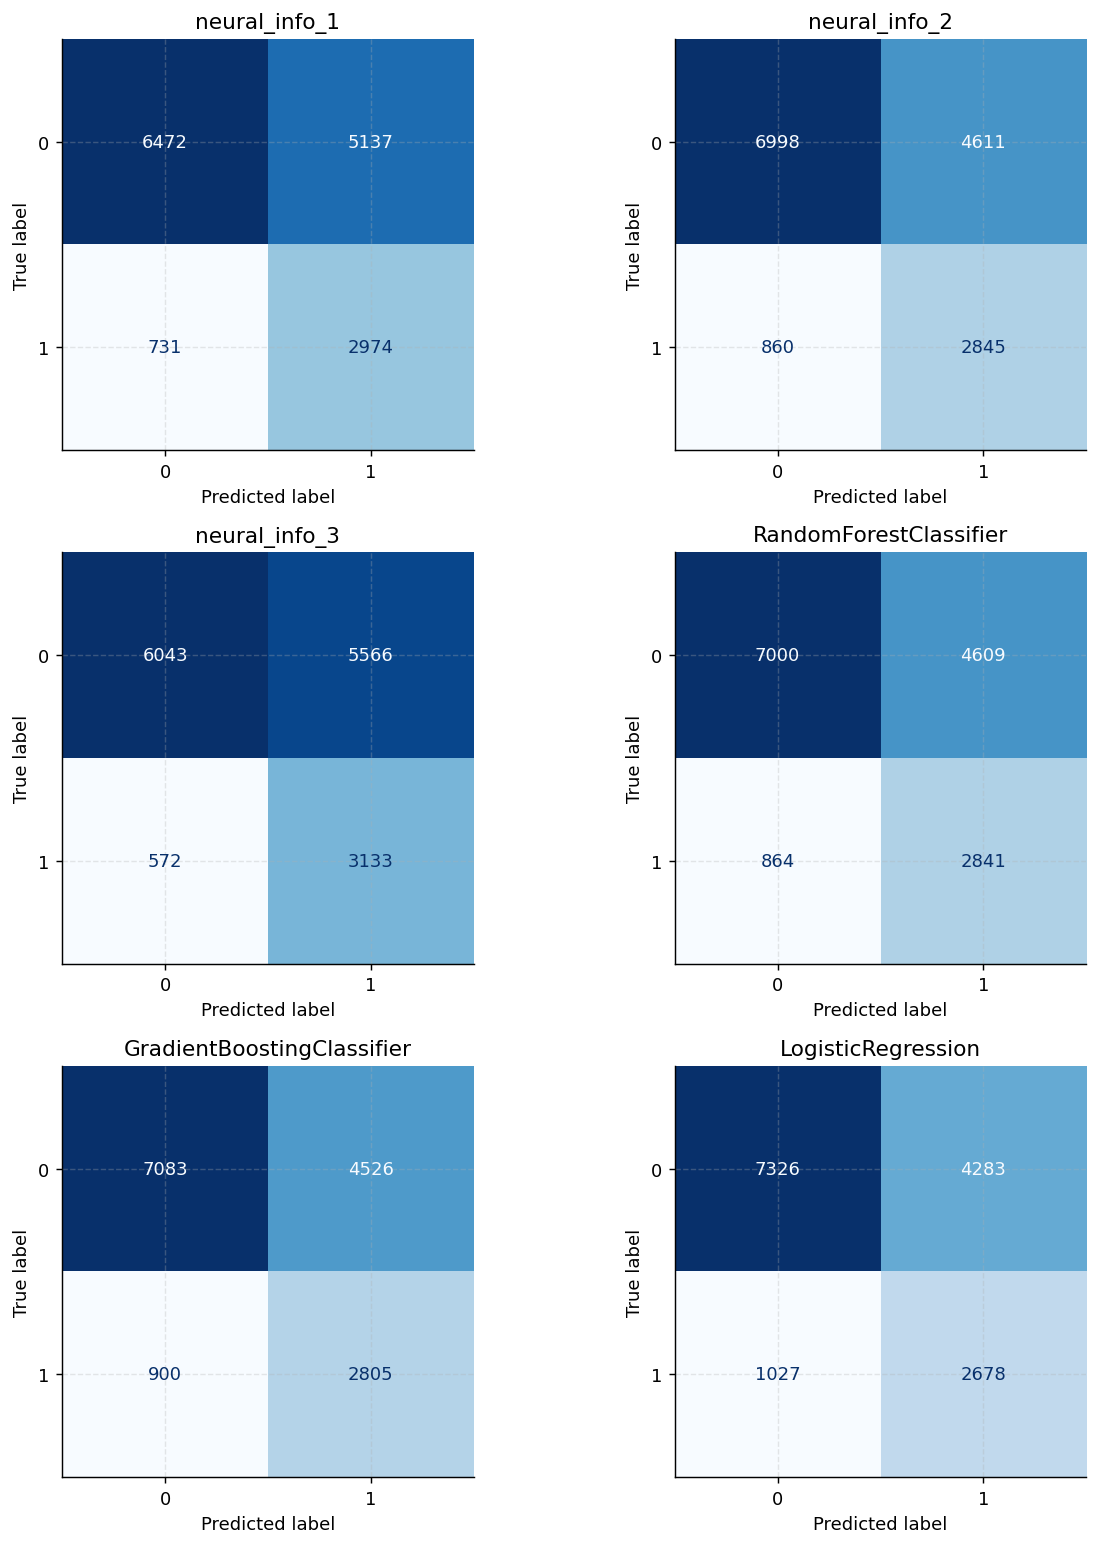

In [154]:
outputs = []
titles = []

with open("best_models.json", "r") as f:
    best_results = json.load(f)

models_to_run = {}
metrics = {}
model_emission = {}

for name, results in best_results.items():

    alpha, dropout, batch, epoch, l2 = results['params']

    models_to_run[name] = MLP(
        neural_dict[name], alpha=alpha, dropout_rate=dropout, 
        batch_size=batch, epoch=epoch, lambda_l2=l2, 
        verbosity=False, model_seed=42)
    
    
models_to_run["RandomForestClassifier"] = RandomForestClassifier(
    n_estimators=200,   
    max_depth=10,        
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)

models_to_run["GradientBoostingClassifier"] = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)

models_to_run["LogisticRegression"] = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='liblinear',
    random_state=42
)

n_models = len(models_to_run)

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.flatten()

for i, (name, model) in enumerate(models_to_run.items()):

    tracker_model = EmissionsTracker(project_name=f"Model_{name}", log_level="error", save_to_file=False)
    tracker_model.start()  

    model.fit(X_train, Y_train)
    print(f"Model {name} done training!")
    tracker_model.stop()

    y_pred = model.predict(X_test)

    f1_best = f1_score(Y_test, y_pred) 
    f2_best = f2_score(Y_test, y_pred, beta=2) 
    recall_score = recall(Y_test, y_pred) 
    precision_score = precision(Y_test, y_pred) 
    accuracy_score = accuracy(Y_test, y_pred) 

    metrics[name] = {
        "f1_metric": f1_best,
        "f2_metric": f2_best, 
        "recall_metric": recall_score, 
        "precision_metric": precision_score, 
        "accuracy_metric": accuracy_score, 
    }

    model_emission[name] = tracker_model._total_emissions

    if name.startswith("neural_"): 
        with open(f"Models/opti_{name}.joblib", "wb") as f: 
            joblib.dump(model, f)

    # matrice de confusion
    matrice = confusion_matrix(Y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=matrice, display_labels=[0, 1])
    
    disp.plot(ax=axes[i], cmap=plt.cm.Blues, colorbar=False)
    axes[i].set_title(name)

for j in range(i + 1, 3 * 2):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

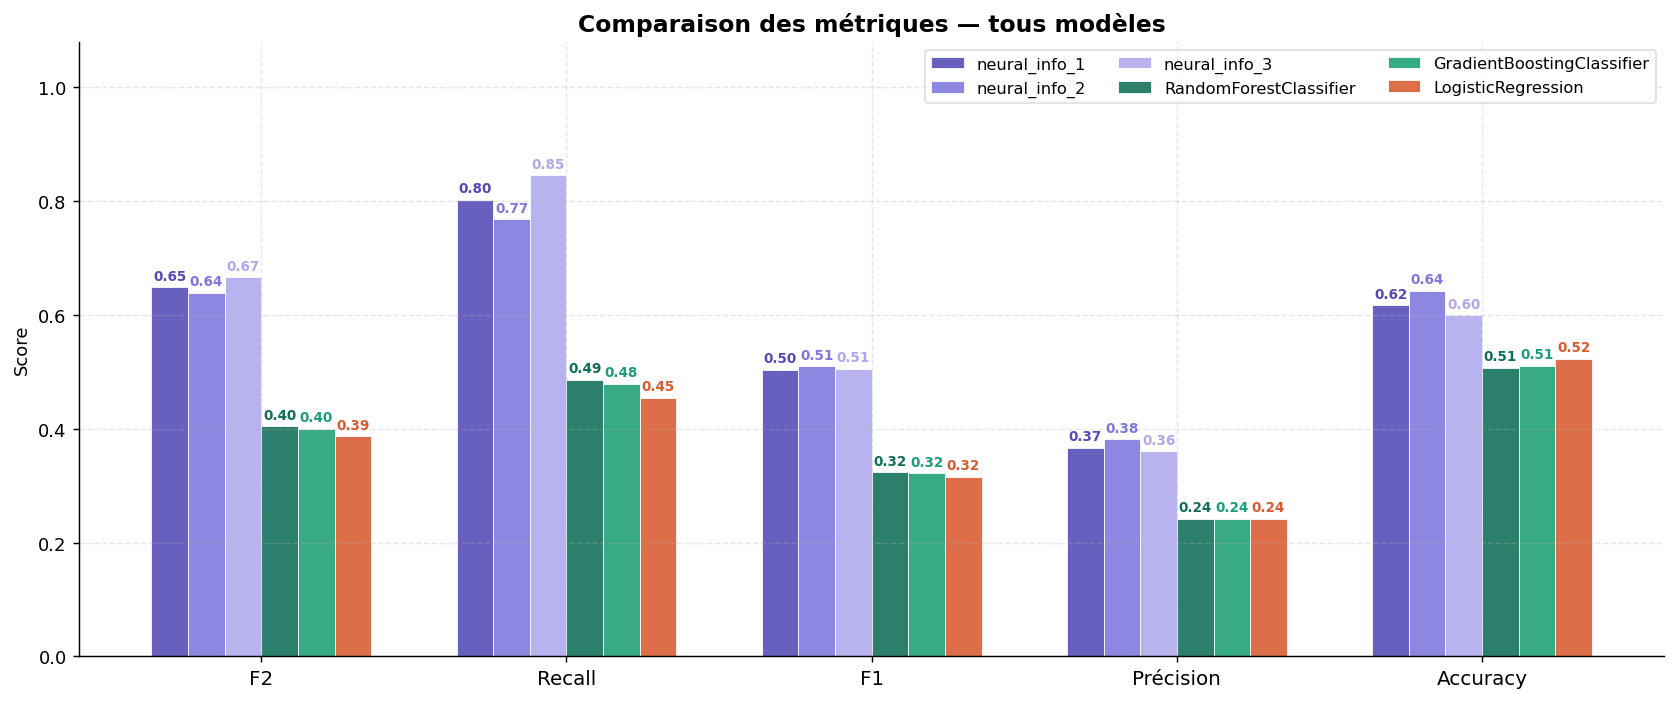

In [160]:
RESULTS = {}

for name, metric in metrics.items():
    RESULTS[name] = {
        "Recall": metric["recall_metric"],
        "Précision": metric["precision_metric"],
        "F1": metric["f1_metric"],
        "F2": metric["f2_metric"],
        "Accuracy": metric["accuracy_metric"]
    }

METRICS = ["F2", "Recall", "F1", "Précision", "Accuracy"]
PALETTE = ["#534AB7", "#7F77DD", "#AFA9EC", "#0F6E56", "#1D9E75", "#D85A30"]

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "figure.dpi": 130,
})

models  = list(RESULTS.keys())
n_m     = len(models)
x       = np.arange(len(METRICS))
width   = 0.12
offsets = np.linspace(-(n_m - 1) / 2 * width, (n_m - 1) / 2 * width, n_m)

fig, ax = plt.subplots(figsize=(13, 5.5))

for i, (model, color) in enumerate(zip(models, PALETTE)):
    vals = [RESULTS[model][m] for m in METRICS]
    bars = ax.bar(x + offsets[i], vals, width, label=model.replace("\n", " "),
                  color=color, alpha=0.88, edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7.5,
                color=color, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(METRICS, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("Comparaison des métriques — tous modèles", fontsize=13, fontweight="bold")
ax.legend(ncol=3, loc="upper right", framealpha=0.9, fontsize=9, edgecolor="#ddd")

fig.tight_layout()
plt.show()

Nous pouvons observer plusieurs choses :
- **Supériorité des performances métriques :** Nos modèles atteignent des scores plus élevés sur l'ensemble des indicateurs. Cela démontre que l'ajustement de nos hyperparamètres (recherche des paramètres idéaux) permet de surpasser significativement les modèles de base utilisés avec leurs configurations par défaut.
- **Optimisation du diagnostic médical :** La comparaison des matrices de confusion révèle une réduction systématique du nombre de faux négatifs dans nos modèles. Dans un contexte de détection du diabète, minimiser les cas où un patient malade n'est pas détecté est crucial. Nos modèles offrent donc une sécurité diagnostique accrue par rapport aux solutions standards.
- **Sélection du modèle optimal :** Parmi nos différentes architectures, le Modèle 3 se distingue comme la solution la plus performante. Il présente le meilleur équilibre entre les métriques globales et la réduction du taux de faux négatifs, s'affirmant ainsi comme le modèle le plus adapté aux contraintes du milieu médical.

## Développement durable

In [161]:
print("\n === Résultats du développement durable ===")
for name, emission in model_emission.items():
    print(f"Model: {name}, Emissions (kg CO2): {emission:.6f}")


 === Résultats du développement durable ===
Model: neural_info_1, Emissions (kg CO2): 0.000014
Model: neural_info_2, Emissions (kg CO2): 0.000011
Model: neural_info_3, Emissions (kg CO2): 0.000021
Model: RandomForestClassifier, Emissions (kg CO2): 0.000001
Model: GradientBoostingClassifier, Emissions (kg CO2): 0.000001
Model: LogisticRegression, Emissions (kg CO2): 0.000000


La notion de développement durable est de plus en plus importante dans le domaine de l'intelligence artificielle, notamment en ce qui concerne l'impact environnemental des modèles d'apprentissage automatique. En effet, l'entraînement de modèles complexes peut nécessiter une grande quantité de ressources informatiques, ce qui peut entraîner une consommation d'énergie importante et une empreinte carbone élevée.

Nous avons analysé la dépense énergétique de chacun des modèles pour voir si le modèle le plus performant est également le plus énergivore, ou si au contraire, il existe un compromis entre performance et consommation d'énergie.

Voici les résultats de la consommation énergétique de chacun des modèles :
| Modèle 1 | Modèle 2 | Modèle 3 | RandomForestClassifier | GradientBoostingClassifier | LogisticRegression |
|----------|----------|----------|----------|-------------------------|---------------------------|
| 0.000014 kg CO2   | 0.000011 kg CO2| 0.000021 kg CO2| 0.000001 kg CO2| 0.000001 kg CO2| 0.000000 kg CO2|

Nous pouvons observer que le modèle 3 (le plus performant) est également le plus énergivore mais sa consommation reste relativement faible voire négligeable. Cependant, nous pouvons observer que les modèles Scikit-learn (RandomForestClassifier, GradientBoostingClassifier et LogisticRegression) sont beaucoup moins énergivores que nos modèles de Deep Learning, ce qui peut être un point à prendre en compte dans le choix du modèle à utiliser en production.

## IA Explicable

Un des principaux enjeux des modèles en machine learning et en deep learning tient à leur manque de lisibilité. Bien qu’ils offrent de très bonnes  performances, leur fonctionnement reste difficile à interpréter. Par exemple, un réseau de neurones peut prédire qu’un patient est atteint d’une maladie, qu’un client risque de partir ou qu’une image présente une anomalie, sans fournir d’explication sur les raisons de cette décision.

Ce manque de transparence soulève plusieurs difficultés. D’une part, il complique la confiance que l’on peut accorder au modèle. D’autre part, il rend plus délicate l’identification d’éventuels biais ou erreurs. Enfin, dans des secteurs sensibles comme la santé pour notre contexte, il est essentiel de pouvoir justifier les décisions prises.

C’est dans ce contexte qu’intervient l’IA explicable, ou XAI (Explainable Artificial Intelligence). Son objectif est de rendre les modèles plus compréhensibles et leurs décisions plus transparentes. Une approche d’explication doit notamment permettre de répondre à des questions telles que : pourquoi une décision a été prise, quelles variables ont le plus influencé le résultat, si les éléments utilisés sont pertinents, ou encore si des biais sont présents dans les données ou le modèle.

Nous allons utiliser deux méthodes d'IA explicable pour analyser notre modèle :
- **SHAP (SHapley Additive exPlanations) :** SHAP est une méthode d’explication basée sur la théorie des jeux. Elle attribue à chaque variable une contribution à la prédiction du modèle, en calculant l’impact de chaque variable sur la prédiction. SHAP permet ainsi de comprendre quelles variables ont le plus influencé la décision du modèle pour une observation donnée.
- **LIME (Local Interpretable Model-agnostic Explanations) :** LIME est une méthode d’explication locale qui génère des explications pour des prédictions individuelles. Elle crée un modèle localement linéaire autour de la prédiction à expliquer, en perturbant les données d’entrée et en observant les changements dans la prédiction. LIME permet ainsi de comprendre quelles variables ont le plus influencé la décision du modèle pour une observation spécifique.

In [ ]:
class XIA:
    def __init__(self, model, X_train, feature_names):
        self.model = model
        self.feature_names = feature_names

        def predict_proba_2d(X):
            pos = self.model._forward_predict(X)
            neg = 1 - pos
            return np.hstack([neg, pos])

        self.predict_proba_2d = predict_proba_2d

        background = shap.sample(X_train, 100)
        self.shap_explainer = shap.KernelExplainer(self.predict_proba_2d, background)

        self.lime_explainer = lime.lime_tabular.LimeTabularExplainer(
            X_train,
            feature_names=feature_names,
            class_names=['No Diabetes', 'Diabetes'],
            discretize_continuous=True
        )

    def explain_shap_instance(self, instance):
        shap_values = self.shap_explainer.shap_values(instance.reshape(1, -1))
        arr = np.array(shap_values)

        # (2, 1, n_features)
        if arr.ndim == 3 and arr.shape[0] == 2:
            return arr[1, 0, :]

        # (1, n_features, 2)
        if arr.ndim == 3 and arr.shape[2] == 2:
            return arr[0, :, 1]

        # (1, n_features)
        if arr.ndim == 2:
            return arr[0, :]

        return arr

    def explain_lime_instance(self, instance, num_features=5):
        exp = self.lime_explainer.explain_instance(
            instance,
            self.predict_proba_2d,
            num_features=num_features
        )
        return exp

  0%|          | 0/1 [00:00<?, ?it/s]

── LIME ──


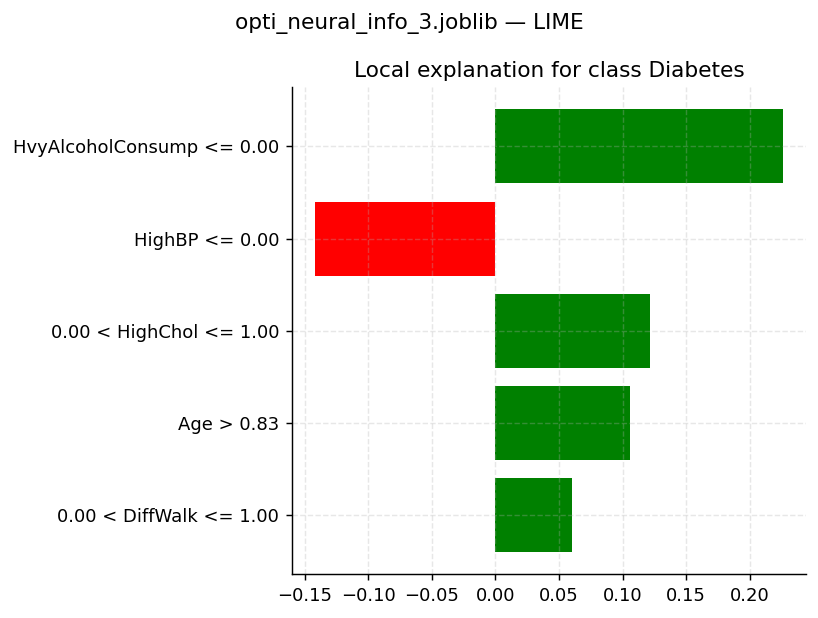

── SHAP ──


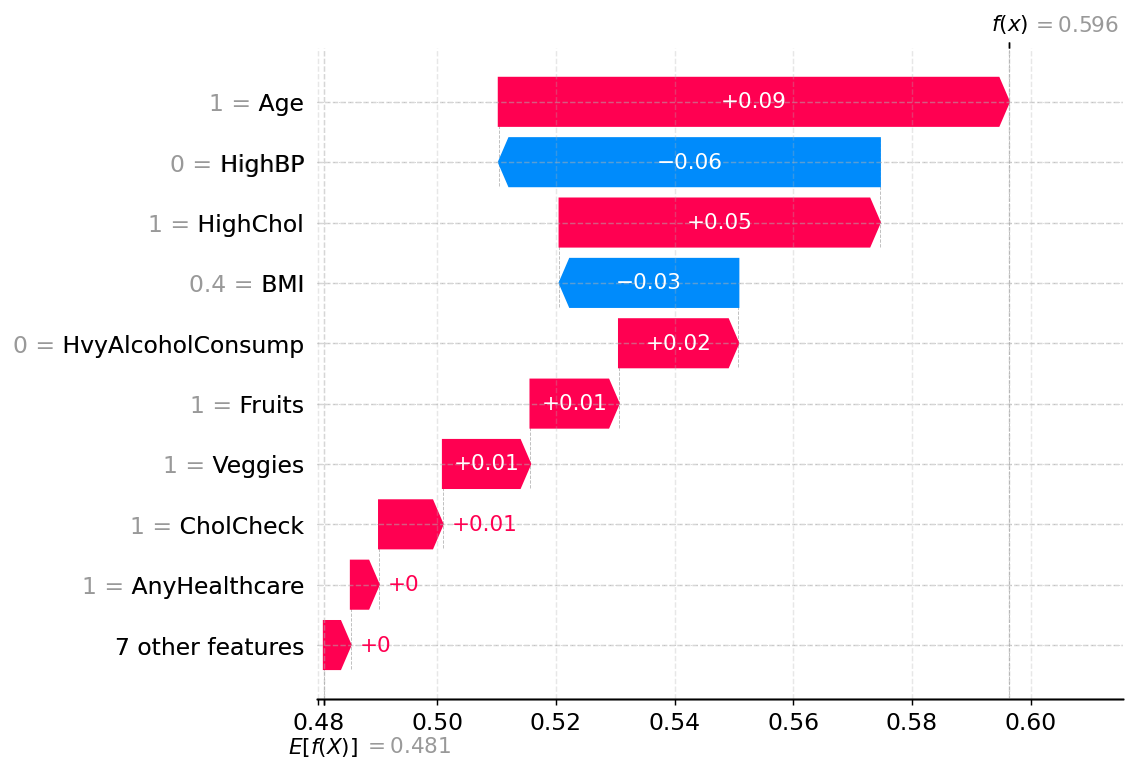

In [162]:
outputs = []
titles = []

selected_model = "opti_neural_info_3.joblib"

model = joblib.load(f"Models/{selected_model}")
model.fit(X_train, Y_train)

feature_names = df_train.drop(columns=['Diabetes_binary']).columns.tolist()

xai = XIA(model, X_train, feature_names)

instance = X_test[0]

shap_values = xai.explain_shap_instance(instance)
lime_exp = xai.explain_lime_instance(instance)

if isinstance(xai.shap_explainer.expected_value, (list, np.ndarray)):
    base_value = xai.shap_explainer.expected_value[1]
else:
    base_value = xai.shap_explainer.expected_value

print(f"── LIME ──")
fig_lime = lime_exp.as_pyplot_figure()
fig_lime.suptitle(f"{selected_model} — LIME", fontsize=12)
plt.tight_layout()
plt.show()

print(f"── SHAP ──")
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values,
        base_values=base_value,
        data=instance,
        feature_names=feature_names
    )
)


Les méthodes montrent reste plutôt unanime sur l'explication des variables qui influent le plus le résultat :
- **SHAP :** La variable qui a le plus d'influence sur la prédiction du modèle est la variable "HighBP" (hypertension), suivie de près par la variable "HighChol" (hypercholestérolémie). Ces deux variables sont des facteurs de risque connus pour le diabète, ce qui est cohérent avec les connaissances médicales. La variable "BMI" (indice de masse corporelle) et l'Age sont également des variables importantes, ce qui est également cohérent avec les facteurs de risque du diabète.
- **LIME :** LIME indique que la variable qui influence le plus est "HvyAlcoholConsump" (consommation excessive d'alcool), suivie de près par "HighBP" (hypertension) et "HighChol" (hypercholestérolémie). Ces variables sont également des facteurs de risque connus pour le diabète, ce qui est cohérent avec les connaissances médicales.

## Implémentation des méthodes de MLOps 

Les méthodes de MLOps dans un projet d'IA est le fait de pouvoir automatiser et industrialiser les différentes étapes du cycle de vie du projet, de la collecte des données à la mise en production du modèle. Nous avons implémenté plusieurs méthodes de MLOps dans notre projet :
- **Sauvegarde des meilleurs hyperparamètres :** Durant la phase de recherche des meilleurs hyperparamètres, nous avons sauvegardé les meilleurs hyperparamètres trouvés pour chaque modèle dans un fichier JSON. Cela nous permet de garder une trace des différentes configurations testées et de pouvoir réutiliser ces hyperparamètres pour l'entrainement final du modèle.
- **Sauvegarde du meilleur modèle :** Après avoir entrainé les modèles avec les meilleurs hyperparamètres, nous avons sauvegardé les modèles avec l'utilisation de la bibliothèque Joblib. Cela nous permet de figer le modèle entrainé avec les meilleurs hyperparamètres et de pouvoir les réutiliser pour la phase de test final ou pour une mise en production.
- **Seed fixe :** Nous avons fixé une seed pour garantir la reproductibilité de nos résultats. En fixant une seed, nous nous assurons que les différentes étapes de notre projet (comme le split des données, l'initialisation des poids du modèle, etc.) sont réalisées de manière déterministe, ce qui permet d'obtenir les mêmes résultats à chaque exécution du code.

## Conclusion

Ce projet a permis de développer un outil de classification binaire pour prédire le risque de diabète en s'appuyant sur les données de l'enquête BRFSS 2015. Le travail s'est articulé autour de quatre axes principaux :

- Pré-traitement et analyse : Nous avons procédé au nettoyage des données en gérant les valeurs manquantes par le mode et en traitant les valeurs aberrantes de l'indice de masse corporelle (BMI) via la méthode de l'écart interquartile (IQR). Pour garantir l'éthique du modèle, les variables socio-économiques comme le revenu et le niveau d'éducation ont été écartées.

- Modélisation et optimisation : Nous avons testé et optimisé les architectures de réseaux de neurones (MLP) par une recherche d'hyperparamètres visant à maximiser le F2-score, métrique privilégiant le rappel pour limiter les faux négatifs en contexte médical.

- Évaluation des performances : Les résultats montrent que nos modèles personnalisés, particulièrement le Modèle 3, surpassent les algorithmes standards (Random Forest, Gradient Boosting, Régression Logistique) en offrant un meilleur équilibre entre précision et sécurité diagnostique.

- Développement durable : L'analyse des émissions de CO2 a révélé que, bien que nos modèles de Deep Learning soient plus énergivores que les solutions Scikit-learn, leur empreinte carbone reste à une échelle négligeable pour ce volume de données.

## Axe d'amélioration

# Annexe - Images

Images performances modèle 1 :

![image](https://github.com/saadaouis/Deep_Learning-project/blob/dev_antoine/Images/Model_1_metrics.png?raw=true)
![image](https://github.com/saadaouis/Deep_Learning-project/blob/dev_antoine/Images/Model_1_matrice.png?raw=true)

Images performances modèle 2 :

![image](https://github.com/saadaouis/Deep_Learning-project/blob/dev_antoine/Images/Model_2_metrics.png?raw=true)
![image](https://github.com/saadaouis/Deep_Learning-project/blob/dev_antoine/Images/Model_2_matrice.png?raw=true)

Images performances modèle 3 :

![image](https://github.com/saadaouis/Deep_Learning-project/blob/dev_antoine/Images/Model_3_metrics.png?raw=true)
![image](https://github.com/saadaouis/Deep_Learning-project/blob/dev_antoine/Images/Model_3_matrice.png?raw=true)